In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust the path if needed
file_path = "/content/drive/MyDrive/GAIAMED/gaia_med_features.csv"
df = pd.read_csv(file_path)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,system:index,month,ndvi_mean,precip_mean,.geo
0,0,2024-01,0.305229,0.042767,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,2024-02,0.412968,0.067175,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,2024-03,0.336807,0.183389,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,2024-04,0.437331,0.017174,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,2024-05,0.372075,0.005193,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [3]:
df = df[['month','ndvi_mean','precip_mean']]
df['month'] = pd.to_datetime(df['month'])

# Quick check for missing values
print(df.isna().sum())


month          0
ndvi_mean      0
precip_mean    0
dtype: int64


In [4]:
# z-score anomalies
df['ndvi_anom'] = (df['ndvi_mean'] - df['ndvi_mean'].mean()) / df['ndvi_mean'].std()
df['precip_anom'] = (df['precip_mean'] - df['precip_mean'].mean()) / df['precip_mean'].std()

# Simple stress rule: low NDVI & low rain
df['stress'] = ((df['ndvi_anom'] < -0.5) & (df['precip_anom'] < -0.5)).astype(int)
df.head()


,month,ndvi_mean,precip_mean,ndvi_anom,precip_anom,stress
0,2024-01-01,0.305229,0.042767,-0.777161,-0.036988,0
1,2024-02-01,0.412968,0.067175,0.449070,0.405970,0
2,2024-03-01,0.336807,0.183389,-0.417757,2.515087,0
3,2024-04-01,0.437331,0.017174,0.726357,-0.501468,0
4,2024-05-01,0.372075,0.005193,-0.016352,-0.718910,0


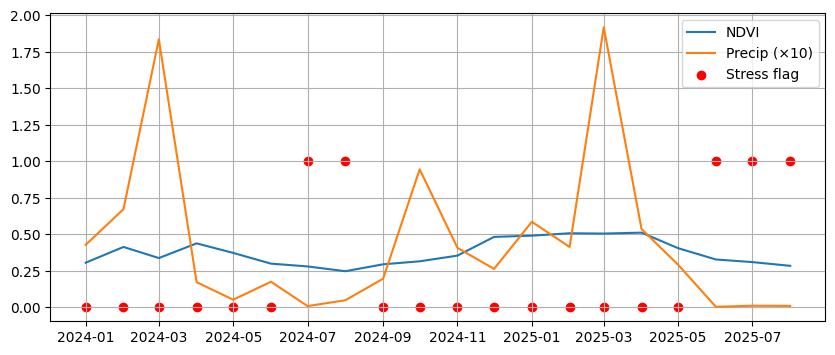

In [5]:
plt.figure(figsize=(10,4))
plt.plot(df['month'], df['ndvi_mean'], label='NDVI')
plt.plot(df['month'], df['precip_mean']*10, label='Precip (×10)')
plt.scatter(df['month'], df['stress'], color='red', label='Stress flag')
plt.legend(); plt.grid(); plt.show()


In [6]:
# Build lagged features (previous-month values)
df['ndvi_prev'] = df['ndvi_mean'].shift(1)
df['precip_prev'] = df['precip_mean'].shift(1)
df = df.dropna()

X = df[['ndvi_mean','precip_mean','ndvi_prev','precip_prev']]
y = df['stress']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
print("Feature importance:", model.feature_importances_)


Feature importance: [0.25236791 0.62619348 0.02863015 0.09280846]


In [7]:
m = folium.Map(location=[36.7, -4.4], zoom_start=8)  # Malaga area

# Average stress color
avg_stress = df['stress'].mean()
color = 'green' if avg_stress < 0.3 else 'orange' if avg_stress < 0.6 else 'red'

popup = f"Avg NDVI: {df['ndvi_mean'].mean():.3f}<br>Avg Rain: {df['precip_mean'].mean():.3f} m<br>Stress Index: {avg_stress:.2f}"
folium.CircleMarker([36.7, -4.4], radius=20, color=color, fill=True,
                    fill_opacity=0.7, popup=popup).add_to(m)

m.save("gaia_med_map.html")
m


# Scaling up

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, folium, geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Load CSV exported from GEE
df = pd.read_csv('/content/drive/MyDrive/GAIAMED/gaia_andalusia_regional.csv')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,system:index,NDVI,cell_id,lat,lon,month,precip_mm,temperature_2m,.geo
0,"0_-53,407",0.279109,cell_-4.71616_36.60635,36.606348,-4.716155,2024-01,82.905297,285.736271,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
1,"0_-52,407",0.307982,cell_-4.62632_36.60635,36.606348,-4.626324,2024-01,95.443849,285.995420,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
2,"0_-51,407",0.181010,cell_-4.53649_36.60635,36.606348,-4.536492,2024-01,90.904070,286.049136,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
3,"0_-50,407",0.016385,cell_-4.44666_36.60635,36.606348,-4.446661,2024-01,73.514359,NaN,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
4,"0_-49,407",0.002871,cell_-4.35683_36.60635,36.606348,-4.356829,2024-01,NaN,NaN,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."


In [9]:
# Keep relevant columns only
df = df[['cell_id','lat','lon','month','NDVI','temperature_2m','precip_mm']]
df['month'] = pd.to_datetime(df['month'])

# Convert Kelvin → °C
df['temp_c'] = df['temperature_2m'] - 273.15
df = df.drop(columns=['temperature_2m'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11560 entries, 0 to 11559
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   cell_id    11560 non-null  object        
 1   lat        11560 non-null  float64       
 2   lon        11560 non-null  float64       
 3   month      11560 non-null  datetime64[ns]
 4   NDVI       11560 non-null  float64       
 5   precip_mm  10620 non-null  float64       
 6   temp_c     10200 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 632.3+ KB
None


In [10]:
def zscore(x): return (x - x.mean())/x.std()

df['ndvi_anom']  = df.groupby('cell_id')['NDVI'].transform(zscore)
df['rain_anom']  = df.groupby('cell_id')['precip_mm'].transform(zscore)
df['temp_anom']  = df.groupby('cell_id')['temp_c'].transform(zscore)

In [11]:
df['stress'] = (
    (df['ndvi_anom'] < -0.5) &
    (df['rain_anom'] < -0.5) &
    (df['temp_anom'] > 0.5)
).astype(int)

In [12]:
# Shift stress by -1 month within each cell → predict next month’s stress
df['stress_next'] = df.groupby('cell_id')['stress'].shift(-1)
df = df.dropna(subset=['stress_next'])


In [13]:
features = ['NDVI','precip_mm','temp_c','ndvi_anom','rain_anom','temp_anom']
X, y = df[features], df['stress_next']

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

print("Model accuracy:", model.score(X, y))
print("Feature importances:", model.feature_importances_)


Model accuracy: 1.0
Feature importances: [0.05220573 0.13063555 0.1884215  0.13228743 0.14423171 0.35221809]


In [14]:
latest = df[df['month'] == df['month'].max()].copy()
latest['stress_prob'] = model.predict_proba(latest[features])[:,1]
latest[['cell_id','stress_prob','lat','lon']].head()


,cell_id,stress_prob,lat,lon
10404,cell_-4.71616_36.60635,0.990,36.606348,-4.716155
10405,cell_-4.62632_36.60635,0.965,36.606348,-4.626324
10406,cell_-4.53649_36.60635,0.105,36.606348,-4.536492
10407,cell_-4.44666_36.60635,0.000,36.606348,-4.446661
10408,cell_-4.35683_36.60635,0.000,36.606348,-4.356829


In [15]:
m = folium.Map(location=[37.0, -3.5], zoom_start=7, tiles='cartodbpositron')

for _, r in latest.iterrows():
    color = (
        'green' if r['stress_prob'] < 0.3 else
        'orange' if r['stress_prob'] < 0.6 else
        'red'
    )
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"{r['cell_id']}<br>Prob={r['stress_prob']:.2f}"
    ).add_to(m)

m.save("gaia_andalusia_map.html")
m


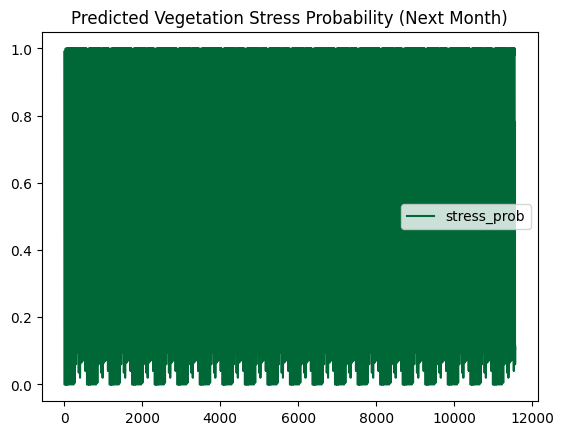

In [17]:
grid = gpd.read_file('/content/drive/MyDrive/GAIAMED/gaia_andalusia_regional.csv')
avg_stress = latest[['cell_id','stress_prob']]
merged = grid.merge(avg_stress, on='cell_id')
merged.plot(column='stress_prob', cmap='RdYlGn_r', legend=True)
plt.title('Predicted Vegetation Stress Probability (Next Month)')
plt.show()
